
# Keogram Retrieval & Optical Aurora Scoring

This notebook implements an **end-to-end optical aurora pipeline** based on hourly RGB keograms from the TREx network:

1. **Download keograms** for selected stations and timestamps using a reusable class-based API.
2. **Process and score keograms** to extract simple image-based proxies of auroral activity.
3. Produce structured outputs (JSON / tables) that can later be aligned with Kp, solar-wind features, or ML targets.

The goal is to build a **lightweight, reproducible optical aurora indicator** that complements geomagnetic indices and enables validation of model predictions against real sky observations.

---


## Why This Notebook Exists

* Provide an **independent optical proxy** of auroral activity.
* Enable comparison between:

  * Optical activity vs. Kp
  * Optical activity vs. ML predictions
* Prepare future work toward:

  * Time-series optical features
  * Site-specific aurora probability
  * Fusion with solar-wind and IMF-driven models.

---

## Expected Outcomes

* Reproducible keogram dataset.
* Simple optical aurora scores per station and hour.
* Foundation for integrating real-sky observations into the aurora prediction stack.


## Part 1 — Keogram Download (TrexKeogramDownloader)

* Uses a dedicated `TrexKeogramDownloader` class.
* Fetches hourly RGB keograms for multiple stations in one call.
* Supports saving to disk and optional display.
* Returns per-request status and metadata.

Typical usage:

* Define date, hour, and station list.
* Instantiate downloader.
* Call `fetch_many(...)`.

Output:

* Local JPG files
* List of dictionaries with URL, device, success flag, and local path.

---

/media/nuopel/DATA/ProjectsAndTools/1_Projects/AI/Capstone_2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MODULE: /media/nuopel/DATA/ProjectsAndTools/1_Projects/AI/Capstone_2/Notebooks/Ext2_Auroravisibility/keogram_utils.py
CLASS: <class 'keogram_utils.TrexKeogramDownloader'>


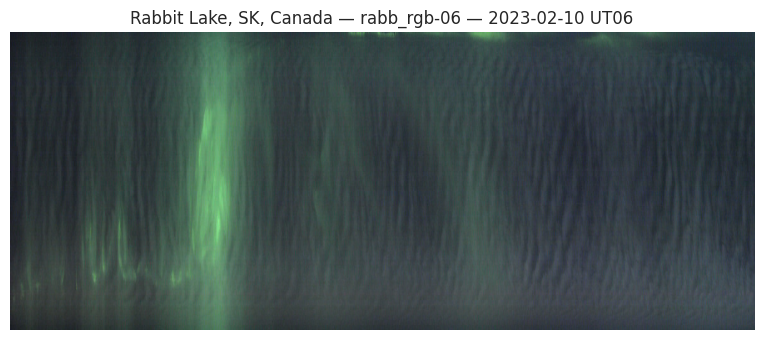

FAIL | yknf_rgb-08  | HTTP-fallback | https://data.phys.ucalgary.ca/sort_by_project/TREx/RGB/stream2/2023/02/10/yknf_rgb-08/ut06/20230210_06_yknf_rgb-08_full-keogram.jpg err=404 not found via HTTP-fallback
OK   | rabb_rgb-06  | API           | https://data.phys.ucalgary.ca/sort_by_project/TREx/RGB/stream2/2023/02/10/rabb_rgb-06/ut06/20230210_06_rabb_rgb-06_full-keogram.jpg saved=keograms_apiA_class/2023-02-10/ut06/20230210_06_rabb_rgb-06_full-keogram.jpg
FAIL | fsmi_rgb-09  | HTTP-fallback | https://data.phys.ucalgary.ca/sort_by_project/TREx/RGB/stream2/2023/02/10/fsmi_rgb-09/ut06/20230210_06_fsmi_rgb-09_full-keogram.jpg err=404 not found via HTTP-fallback

[TIMER] elapsed: 8.444s


In [1]:
from pathlib import Path

import keogram_utils, importlib
print("MODULE:", keogram_utils.__file__)
importlib.reload(keogram_utils)
print("CLASS:", keogram_utils.TrexKeogramDownloader)
from keogram_utils import TrexKeogramDownloader
import time

_t0 = time.perf_counter()

DATE = "2023-02-10"
HOUR = 6

sites = [
    ("Yellowknife, NWT, Canada", "yknf", "yknf_rgb-08"),
    ("Rabbit Lake, SK, Canada", "rabb", "rabb_rgb-06"),
    ("Fort Smith, NWT, Canada", "fsmi", "fsmi_rgb-09"),
]

dl = TrexKeogramDownloader(
    save_dir=Path("./keograms_apiA_class"),
    stream=2,  # matches your working URL pattern
    dataset="TREX_RGB_HOURLY_KEOGRAM",
    timeout=60,
)

results = dl.fetch_many(DATE, HOUR, sites, save=True, display=True)

# Console summary
for r in results:
    status = "OK" if r["ok"] else "FAIL"
    extra = f" saved={r['local_path']}" if r["ok"] else f" err={r['error']}"
    print(f"{status:4s} | {r['device']:12s} | {r['source']:13s} | {r['url']}{extra}")

print(f"\n[TIMER] elapsed: {time.perf_counter()-_t0:.3f}s")





## Part 2 — Keogram Scoring (KeogramScorer)

* Uses a `KeogramScorer` class to analyze saved images.
* Computes simple image statistics (brightness, color activity, contrast, etc.).
* Converts each keogram into a **numeric aurora-activity score**.

Typical usage:

* Point scorer to a folder of keograms.
* Run `score_folder(...)`.

Output:

* List of per-image feature dictionaries.
* Optional JSON export for downstream pipelines.

---



In [53]:
# --- Keogram processing: class-based scorer ---
from pathlib import Path
print("MODULE:", keogram_utils.__file__)
importlib.reload(keogram_utils)
print("CLASS:", keogram_utils.KeogramScorer)
from keogram_utils import KeogramScorer

scorer = KeogramScorer()

# Example: run on saved JPGs under ./keograms / ./keograms_apiA / ./keograms_apiB
rows = scorer.score_folder(Path('./keograms_apiA_class'), save_json=True)
print('scored', len(rows))
print(rows[:3])


MODULE: /media/nuopel/DATA/ProjectsAndTools/1_Projects/AI/Capstone_2/Notebooks/Ext2_Auroravisibility/keogram_utils.py
CLASS: <class 'keogram_utils.KeogramScorer'>
scored 12
[{'green_score': 0.0033773167268798337, 'green_coverage': 0.05667094748858448, 'green_intensity': 0.05959520488977432, 'red_score': 5.894290952045964e-06, 'red_coverage': 0.00014507229832572298, 'red_intensity': 0.040630023926496506, 'white_score': 0.0, 'white_coverage': 0.0, 'white_brightness': 0.0, 'black_score': 0.00046765423724300244, 'black_coverage': 0.0005065639269406393, 'black_darkness': 0.9231889843940735, 'aurora_score': 0.0033773167268798337, 'path': 'keograms_apiA_class/2025-02-02/ut06/20250202_06_fsmi_rgb-09_full-keogram.jpg'}, {'green_score': 0.003805678582408634, 'green_coverage': 0.05445681126331811, 'green_intensity': 0.06988434493541718, 'red_score': 3.5906674076705217e-06, 'red_coverage': 8.323820395738203e-05, 'red_intensity': 0.04313725233078003, 'white_score': 0.0, 'white_coverage': 0.0, 'whit